# python网络编程

网络编程对所有开发语言都是一样的，Python也不例外。用Python进行网络编程，就是在Python程序本身这个进程内，连接别的服务器进程的通信端口进行通信。



## TCP/IP简介

然大家现在对互联网很熟悉，但是计算机网络的出现比互联网要早很多。

计算机为了联网，就必须规定通信协议，早期的计算机网络，都是由各厂商自己规定一套协议，IBM、Apple和Microsoft都有各自的网络协议，互不兼容，这就好比一群人有的说英语，有的说中文，有的说德语，说同一种语言的人可以交流，不同的语言之间就不行了。

为了把全世界的所有不同类型的计算机都连接起来，就必须规定一套全球通用的协议，为了实现互联网这个目标，互联网协议簇（Internet Protocol Suite）就是通用协议标准。Internet是由inter和net两个单词组合起来的，原意就是连接“网络”的网络，有了Internet，任何私有网络，只要支持这个协议，就可以联入互联网。

因为互联网协议包含了上百种协议标准，但是最重要的两个协议是TCP和IP协议，所以，大家把互联网的协议简称TCP/IP协议。

通信的时候，双方必须知道对方的标识，好比发邮件必须知道对方的邮件地址。互联网上每个计算机的唯一标识就是IP地址，类似123.123.123.123。如果一台计算机同时接入到两个或更多的网络，比如路由器，它就会有两个或多个IP地址，所以，IP地址对应的实际上是计算机的网络接口，通常是网卡。

IP协议负责把数据从一台计算机通过网络发送到另一台计算机。数据被分割成一小块一小块，然后通过IP包发送出去。由于互联网链路复杂，两台计算机之间经常有多条线路，因此，路由器就负责决定如何把一个IP包转发出去。IP包的特点是按块发送，途径多个路由，但不保证能到达，也不保证顺序到达。

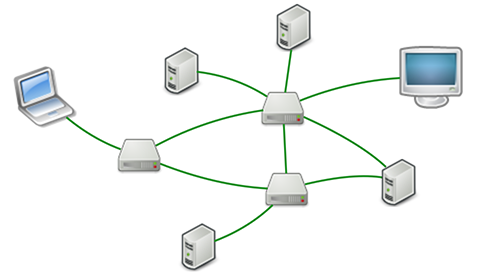

IP地址实际上是一个32位整数（称为IPv4），以字符串表示的IP地址如192.168.0.1实际上是把32位整数按8位分组后的数字表示，目的是便于阅读。

IPv6地址实际上是一个128位整数，它是目前使用的IPv4的升级版，以字符串表示类似于2001:0db8:85a3:0042:1000:8a2e:0370:7334。

TCP协议则是建立在IP协议之上的。TCP协议负责在两台计算机之间建立可靠连接，保证数据包按顺序到达。TCP协议会通过握手建立连接，然后，对每个IP包编号，确保对方按顺序收到，如果包丢掉了，就自动重发。

许多常用的更高级的协议都是建立在TCP协议基础上的，比如用于浏览器的HTTP协议、发送邮件的SMTP协议等。

一个TCP报文除了包含要传输的数据外，还包含源IP地址和目标IP地址，源端口和目标端口。

端口有什么作用？在两台计算机通信时，只发IP地址是不够的，因为同一台计算机上跑着多个网络程序。一个TCP报文来了之后，到底是交给浏览器还是QQ，就需要端口号来区分。每个网络程序都向操作系统申请唯一的端口号，这样，两个进程在两台计算机之间建立网络连接就需要各自的IP地址和各自的端口号。

一个进程也可能同时与多个计算机建立链接，因此它会申请很多端口。

了解了TCP/IP协议的基本概念，IP地址和端口的概念，我们就可以开始进行网络编程了。

## TCP编程

Socket是网络编程的一个抽象概念。通常我们用一个Socket表示“打开了一个网络链接”，而打开一个Socket需要知道目标计算机的IP地址和端口号，再指定协议类型即可。



### 客户端
大多数连接都是可靠的TCP连接。创建TCP连接时，主动发起连接的叫客户端，被动响应连接的叫服务器。

举个例子，当我们在浏览器中访问新浪时，我们自己的计算机就是客户端，浏览器会主动向新浪的服务器发起连接。如果一切顺利，新浪的服务器接受了我们的连接，一个TCP连接就建立起来的，后面的通信就是发送网页内容了。

所以，我们要创建一个基于TCP连接的Socket，可以这样做：


In [ ]:
# 导入socket库:
import socket

# 创建一个socket:
s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
# 建立连接:
s.connect(('www.sina.com.cn', 80))

创建Socket时，AF_INET指定使用IPv4协议，如果要用更先进的IPv6，就指定为AF_INET6。SOCK_STREAM指定使用面向流的TCP协议，这样，一个Socket对象就创建成功，但是还没有建立连接。

In [ ]:
# 发送数据:
s.send(b'GET / HTTP/1.1\r\nHost: www.sina.com.cn\r\nConnection: close\r\n\r\n')

发送的文本格式必须符合HTTP标准，如果格式没问题，接下来就可以接收新浪服务器返回的数据了：

In [ ]:
# 接收数据:
buffer = []
while True:
    # 每次最多接收1k字节:
    d = s.recv(1024)
    if d:
        buffer.append(d)
    else:
        break
data = b''.join(buffer)


我们接收完数据后，调用close()方法关闭Socket，这样，一次完整的网络通信就结束了：

In [ ]:
s.close()

In [ ]:
import socket

client = socket.socket()
client.connect(("127.0.0.1",8899))

# 发消息
client.send("Hello TCP Server".encode("utf-8"))
# 收回复
res = client.recv(1024)
print(res.decode("utf-8"))

client.close()

### 服务器

In [ ]:
import socket

# 1. 配置参数
HOST = "0.0.0.0"    # 0.0.0.0：监听本机所有网卡（局域网/本机都能连），写127.0.0.1仅本机访问
PORT = 8899         # 端口 >1024，避开系统保留端口
BUFF_SIZE = 1024    # 单次缓冲区大小，一次最多收1024字节数据

def start_tcp_server():
    # 2. 创建TCP套接字对象
    # socket.AF_INET: IPv4协议；socket.SOCK_STREAM：TCP流式
    server_sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)

    # 端口复用：服务重启瞬间端口被TIME_WAIT占用，设置后可立刻重启不报错
    server_sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)

    # 3. 绑定IP+端口
    server_sock.bind((HOST, PORT))

    # 4. 开启监听，参数5：挂起连接队列最大长度（排队等待接入的客户端）
    server_sock.listen(5)
    print(f"✅ TCP服务启动成功，监听地址：{HOST}:{PORT}")
    print("👉 等待客户端接入...")

    try:
        while True:
            # 阻塞等待客户端连接，有客户端connect才往下走
            # conn: 新的通信套接字（和客户端一对一专用）；addr=(客户端IP,客户端端口)
            conn, client_addr = server_sock.accept()
            print(f"\n🔌 新客户端接入：{client_addr}")

            # 循环收发单客户端消息
            with conn:
                while True:
                    # recv阻塞接收客户端数据，无数据阻塞等待
                    recv_data = conn.recv(BUFF_SIZE)
                    # recv返回空bytes=b'' → 客户端主动关闭连接
                    if not recv_data:
                        print(f"❌ 客户端 {client_addr} 断开连接")
                        break

                    # bytes解码成字符串（客户端utf8发数据）
                    recv_str = recv_data.decode("utf-8")
                    print(f"[{client_addr}]收到：{recv_str}")

                    # 构造回复数据，编码为bytes发回客户端
                    send_str = f"服务端已收到：{recv_str}"
                    conn.send(send_str.encode("utf-8"))

    except KeyboardInterrupt:
        print("\n🛑 手动终止服务")
    finally:
        # 关闭服务端主socket
        server_sock.close()

# 启动服务
if __name__ == "__main__":
    start_tcp_server()

## UDP编程

TCP是建立可靠连接，并且通信双方都可以以流的形式发送数据。相对TCP，UDP则是面向无连接的协议。

使用UDP协议时，不需要建立连接，只需要知道对方的IP地址和端口号，就可以直接发数据包。但是，能不能到达就不知道了。

虽然用UDP传输数据不可靠，但它的优点是和TCP比，速度快，对于不要求可靠到达的数据，就可以使用UDP协议。

### UDP 服务端

In [ ]:
import socket

# 配置
HOST = "0.0.0.0"   # 监听所有网卡
PORT = 8899
BUF_SIZE = 1024

def start_udp_server():
    # AF_INET IPv4，SOCK_DGRAM = UDP数据报
    server = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
    # 端口复用
    server.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
    # UDP不需要listen()、不需要accept()，直接bind
    server.bind((HOST, PORT))
    print(f"UDP服务启动 {HOST}:{PORT}，等待数据...")

    while True:
        # recvfrom：(数据bytes, (客户端ip,端口))
        data, client_addr = server.recvfrom(BUF_SIZE)
        # 解码
        msg = data.decode("utf-8")
        print(f"[{client_addr}] 收到：{msg}")

        # 回包：sendto(数据, 目标地址)
        resp = f"UDP服务应答：{msg}".encode("utf-8")
        server.sendto(resp, client_addr)

if __name__ == "__main__":
    start_udp_server()

### UDP 客户端

In [ ]:
import socket

SERVER_IP = "127.0.0.1"
SERVER_PORT = 8899
BUF_SIZE = 1024

def udp_client():
    client = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)

    send_msg = "Hello UDP".encode("utf-8")
    # UDP发数据不用connect，直接sendto
    client.sendto(send_msg, (SERVER_IP, SERVER_PORT))

    # 接收服务端回执
    recv_data, _ = client.recvfrom(BUF_SIZE)
    print("服务端返回：", recv_data.decode("utf-8"))

    client.close()

if __name__ == "__main__":
    udp_client()

UDP的使用与TCP类似，但是不需要建立连接。此外，服务器绑定UDP端口和TCP端口互不冲突，也就是说，UDP的9999端口与TCP的9999端口可以各自绑定。

关键区别（TCP vs UDP）

TCP：SOCK_STREAM → bind→listen→accept→recv/send，面向连接，一对一通信套接字

UDP：SOCK_DGRAM → 只 bind，无 listen/accept，recvfrom/sendto，自带对方地址

UDP 不会出现 b'' 断开，无连接概念，客户端下线服务端无感